# 06 — Hypothesis Testing
**References:** Neyman & Pearson (1933) · Fisher (1925) · Wasserstein et al. (2019) *ASA statement on p-values*

## Narrative thread
```
Framework -> Type I/II errors and power -> t-tests -> Chi-square -> p-value controversy -> multiple testing
```

## The Neyman-Pearson framework

| Component | Symbol | Definition |
|---|---|---|
| Null hypothesis | $H_0$ | Default belief; assume true until evidence against |
| Alternative | $H_1$ | What we want to detect |
| Test statistic | $T$ | Function of data; large values favor $H_1$ |
| Rejection region | $R$ | Values of $T$ for which we reject $H_0$ |
| Significance level | $\alpha$ | $P(\text{reject } H_0 \mid H_0 \text{ true})$ — type I error rate |
| Power | $1-\beta$ | $P(\text{reject } H_0 \mid H_1 \text{ true})$ |
| p-value | $p$ | $P(T \geq t_{obs} \mid H_0)$ — evidence against $H_0$ |

## Error types

| | $H_0$ true | $H_0$ false |
|---|---|---|
| **Reject $H_0$** | Type I error ($\alpha$) | Correct (power = $1-\beta$) |
| **Fail to reject** | Correct ($1-\alpha$) | Type II error ($\beta$) |

Reducing $\alpha$ increases $\beta$ (all else equal). The only way to reduce both simultaneously is to increase $n$.

## Common tests

| Test | $H_0$ | Statistic | Distribution under $H_0$ |
|---|---|---|---|
| One-sample $t$ | $\mu = \mu_0$ | $t = (\bar{x}-\mu_0)/(s/\sqrt{n})$ | $t_{n-1}$ |
| Two-sample $t$ | $\mu_1 = \mu_2$ | Welch's $t$ | $t_{df}$ (Welch-Satterthwaite) |
| Paired $t$ | $\mu_D = 0$ | $t = \bar{d}/(s_d/\sqrt{n})$ | $t_{n-1}$ |
| $\chi^2$ goodness-of-fit | Observed = Expected | $\sum(O_i-E_i)^2/E_i$ | $\chi^2_{k-1}$ |
| $\chi^2$ independence | $X \perp Y$ | Same statistic | $\chi^2_{(r-1)(c-1)}$ |

## The p-value controversy

> **ASA (2016):** "A p-value does not measure the probability that the studied hypothesis
> is true, or the probability that the data were produced by random chance alone."

**What p-values do NOT tell you:**
- The probability $H_0$ is true
- Whether the effect is large or important
- Whether the result will replicate

**What they DO tell you:** the probability of observing data at least as extreme as yours,
*assuming $H_0$ is true*. A small p-value means the data are surprising under $H_0$.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

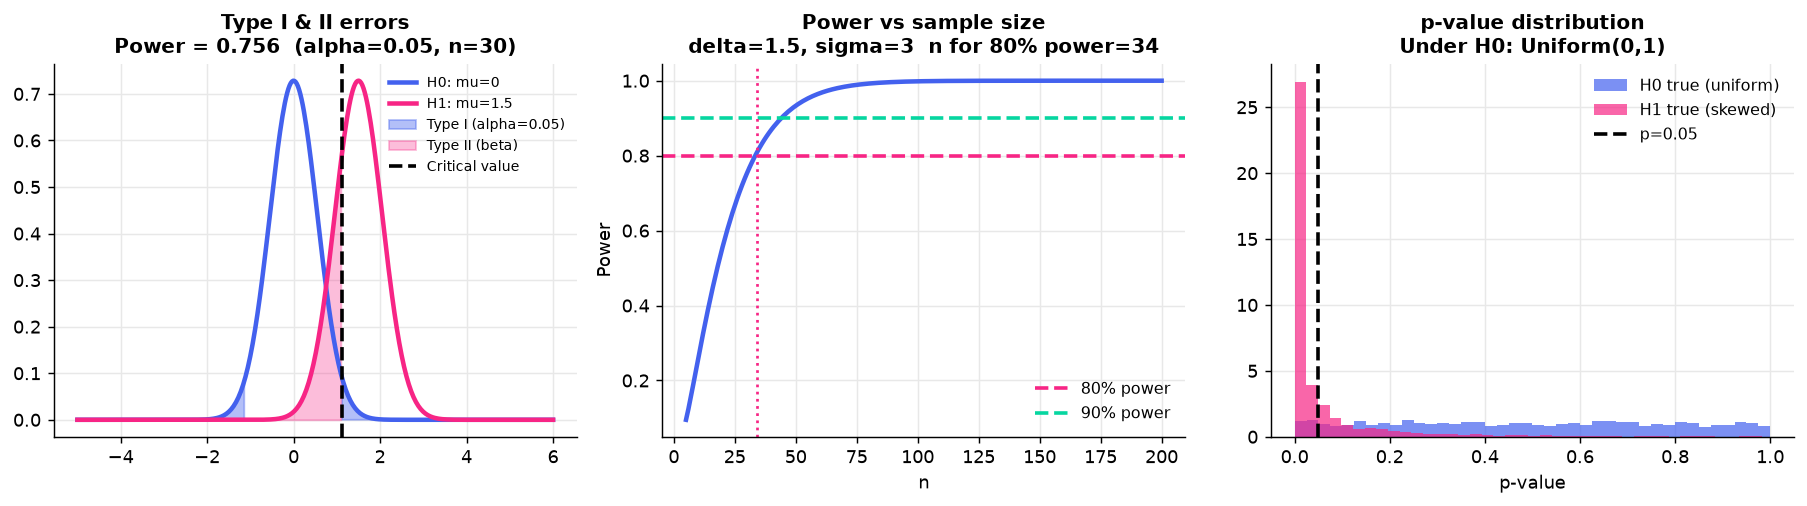

In [2]:
# ── Type I / II errors: visual demonstration ─────────────────────────────
from scipy.stats import norm, t as t_dist

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# One-sample t-test illustration
mu0, mu1, sigma, n_test = 0, 1.5, 3, 30
alpha = 0.05
se = sigma / np.sqrt(n_test)
t_crit = t_dist.ppf(1 - alpha/2, df=n_test-1)

x = np.linspace(-5, 6, 400)
ax = axes[0]
ax.plot(x, norm.pdf(x, mu0, se), color='#4361ee', lw=2.5, label=f'H0: mu={mu0}')
ax.plot(x, norm.pdf(x, mu1, se), color='#f72585', lw=2.5, label=f'H1: mu={mu1}')
ax.fill_between(x, norm.pdf(x, mu0, se), where=(np.abs(x) >= t_crit*se),
                color='#4361ee', alpha=0.4, label=f'Type I (alpha={alpha})')
ax.fill_between(x, norm.pdf(x, mu1, se), where=(x <= t_crit*se),
                color='#f72585', alpha=0.3, label=f'Type II (beta)')
ax.axvline(t_crit*se, color='black', lw=2, linestyle='--', label=f'Critical value')
power = 1 - norm.cdf(t_crit*se, mu1, se) + norm.cdf(-t_crit*se, mu1, se)
ax.set_title(f'Type I & II errors\nPower = {power:.3f}  (alpha={alpha}, n={n_test})')
ax.legend(fontsize=7.5)

# Power curve as function of n
ns = np.arange(5, 201)
delta = mu1
powers = [1 - t_dist.cdf(t_dist.ppf(1-alpha/2, df=n-1), df=n-1, loc=delta/(sigma/np.sqrt(n)))
          + t_dist.cdf(-t_dist.ppf(1-alpha/2, df=n-1), df=n-1, loc=delta/(sigma/np.sqrt(n)))
          for n in ns]
axes[1].plot(ns, powers, color='#4361ee', lw=2.5)
axes[1].axhline(0.80, color='#f72585', lw=2, linestyle='--', label='80% power')
axes[1].axhline(0.90, color='#06d6a0', lw=2, linestyle='--', label='90% power')
n80 = ns[np.argmax(np.array(powers) >= 0.80)]
axes[1].axvline(n80, color='#f72585', lw=1.5, linestyle=':')
axes[1].set_xlabel('n'); axes[1].set_ylabel('Power')
axes[1].set_title(f'Power vs sample size\ndelta={delta}, sigma={sigma}  n for 80% power={n80}')
axes[1].legend(fontsize=9)

# p-value distribution under H0 vs H1
p_under_h0 = [stats.ttest_1samp(np.random.normal(0, sigma, n_test), 0).pvalue for _ in range(3000)]
p_under_h1 = [stats.ttest_1samp(np.random.normal(mu1, sigma, n_test), 0).pvalue for _ in range(3000)]
axes[2].hist(p_under_h0, bins=40, alpha=0.7, color='#4361ee', density=True, label='H0 true (uniform)')
axes[2].hist(p_under_h1, bins=40, alpha=0.7, color='#f72585', density=True, label='H1 true (skewed)')
axes[2].axvline(0.05, color='black', lw=2, linestyle='--', label='p=0.05')
axes[2].set_xlabel('p-value'); axes[2].set_title('p-value distribution\nUnder H0: Uniform(0,1)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [3]:
# ── t-tests: one-sample, two-sample, paired ──────────────────────────────
np.random.seed(7)

# One-sample t-test: is average sleep >= 8 hours?
sleep = np.random.normal(7.1, 1.3, 45)
t_stat, p_val = stats.ttest_1samp(sleep, popmean=8.0)
ci = stats.t.interval(0.95, df=44, loc=sleep.mean(), scale=stats.sem(sleep))
print('One-sample t-test: H0: mu=8 hours of sleep')
print(f'  xbar={sleep.mean():.3f}  s={sleep.std():.3f}  n={len(sleep)}')
print(f'  t={t_stat:.4f}  p={p_val:.4f}  95% CI: [{ci[0]:.3f}, {ci[1]:.3f}]')
print(f'  Decision: {"Reject H0" if p_val < 0.05 else "Fail to reject H0"}')
print()

# Two-sample t-test (Welch): do two groups differ?
groupA = np.random.normal(72, 15, 40)
groupB = np.random.normal(78, 18, 45)
t2, p2 = stats.ttest_ind(groupA, groupB, equal_var=False)
print("Two-sample Welch t-test: H0: mu_A = mu_B")
print(f'  GroupA: mean={groupA.mean():.2f}  GroupB: mean={groupB.mean():.2f}')
print(f'  t={t2:.4f}  p={p2:.4f}')
print(f'  Effect size (Cohen d): {(groupA.mean()-groupB.mean())/np.sqrt((groupA.var()+groupB.var())/2):.3f}')
print()

# Paired t-test: before/after
before = np.random.normal(120, 15, 30)
after  = before - np.random.normal(8, 10, 30)  # treatment reduces by ~8
t3, p3 = stats.ttest_rel(before, after)
print("Paired t-test: H0: mu_before = mu_after")
print(f'  Mean difference: {(before-after).mean():.3f}  SD diff: {(before-after).std():.3f}')
print(f'  t={t3:.4f}  p={p3:.4f}')

# ── Multiple testing: FWER and FDR ───────────────────────────────────────
from statsmodels.stats.multitest import multipletests

print()
print('Multiple testing correction:')
# Simulate 100 tests: 90 null, 10 with real effects
null_pvals  = np.random.uniform(0, 1, 90)
alt_pvals   = np.random.beta(0.5, 5, 10)  # small p-values
all_pvals   = np.concatenate([null_pvals, alt_pvals])
true_null   = np.array([True]*90 + [False]*10)

reject_raw = all_pvals < 0.05
_, reject_bonf, _, _ = multipletests(all_pvals, alpha=0.05, method='bonferroni')
_, reject_bh,   _, _ = multipletests(all_pvals, alpha=0.05, method='fdr_bh')

print(f'  No correction:  {reject_raw.sum()} rejections  (FP={reject_raw[true_null].sum()} false positives)')
print(f'  Bonferroni:     {reject_bonf.sum()} rejections  (FP={reject_bonf[true_null].sum()})')
print(f'  Benjamini-H:    {reject_bh.sum()} rejections   (FP={reject_bh[true_null].sum()})')

One-sample t-test: H0: mu=8 hours of sleep
  xbar=6.949  s=1.370  n=45
  t=-5.0923  p=0.0000  95% CI: [6.532, 7.365]
  Decision: Reject H0

Two-sample Welch t-test: H0: mu_A = mu_B
  GroupA: mean=72.42  GroupB: mean=82.06
  t=-2.9549  p=0.0041
  Effect size (Cohen d): -0.651

Paired t-test: H0: mu_before = mu_after
  Mean difference: 7.799  SD diff: 9.302
  t=4.5153  p=0.0001

Multiple testing correction:
  No correction:  11 rejections  (FP=5 false positives)
  Bonferroni:     97.28731289186226 rejections  (FP=89.56419539189979)
  Benjamini-H:    72.4957780857759 rejections   (FP=69.26199774166652)
